In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [14]:
#Load Data
df = pd.read_csv("temp_vanilla.csv")

X = df[[
    "temp_morning",
    "temp_afternoon",
    "temp_evening"
]].values

y = df["next_day_temp"].values.reshape(-1,1)

In [15]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(y_train.shape)


(80, 3)
(80, 1)


In [16]:
# =====================================================
# STANDARD SCALING
# =====================================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)



In [5]:
input_size = 1 # d=1
hidden_size = 8 # h =8
output_size = 1 # k=1
T=3

learning_rate = 0.001
epochs = 1000


In [6]:
Wxh = np.random.randn(hidden_size,input_size)*0.1
Whh = np.random.randn(hidden_size,hidden_size)*0.1

bh = np.zeros((hidden_size,1))

Why = np.random.randn(output_size,hidden_size)*0.1
by = np.zeros((output_size,1))

In [7]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for n in range(len(X_train)):
        h_prev = np.zeros((hidden_size,1))

        xs = []
        hs = []


        for t in range(T):

            x_t = np.array([[X_train[n,t]]])

            h_prev = np.tanh(
                Wxh @ x_t +
                Whh @ h_prev +
                bh
            )

            xs.append(x_t)
            hs.append(h_prev)

        y_hat = Why @ hs[T-1] + by

        target = np.array([[y_train[n,0]]])

        loss = 0.5*np.sum((y_hat-target)**2)

        total_loss += loss

        dy = y_hat - target

        dWhy = dy @ hs[T-1].T
        dby = dy

        dWxh = np.zeros_like(Wxh)
        dWhh = np.zeros_like(Whh)
        dbh = np.zeros_like(bh)

        dh_next = Why.T @ dy # dh_T

        for t in reversed(range(3)): #t=2,1,0

            h = hs[t]

            dh = dh_next

            da = dh * (1 - h**2)

            dbh += da

            dWxh += da @ xs[t].T

            if t > 0:
                dWhh += da @ hs[t-1].T

            dh_next = Whh.T @ da


        Wxh -= learning_rate*dWxh
        Whh -= learning_rate*dWhh
        bh  -= learning_rate*dbh

        Why -= learning_rate*dWhy
        by  -= learning_rate*dby

    loss_history.append(total_loss)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d}  Loss = {total_loss/len(X_train):.6f}"
        )


Epoch    0  Loss = 0.509555
Epoch  100  Loss = 0.045401
Epoch  200  Loss = 0.045365
Epoch  300  Loss = 0.045340
Epoch  400  Loss = 0.045321
Epoch  500  Loss = 0.045305
Epoch  600  Loss = 0.045290
Epoch  700  Loss = 0.045277
Epoch  800  Loss = 0.045264
Epoch  900  Loss = 0.045250


In [8]:
# =====================================================
# TESTING
# =====================================================

predictions = []

for n in range(len(X_test)):

    h_prev = np.zeros((hidden_size,1))

    for t in range(3):

        x_t = np.array([[X_test[n,t]]])

        h_prev = np.tanh(
            Wxh @ x_t +
            Whh @ h_prev +
            bh
        )

    y_hat = Why @ h_prev + by

    predictions.append(y_hat[0,0])

predictions = np.array(predictions).reshape(-1,1)


In [9]:
# =====================================================
# INVERSE TRANSFORM
# =====================================================

predictions = y_scaler.inverse_transform(predictions)

actual = y_test


In [10]:
# =====================================================
# EVALUATION
# =====================================================

mse = mean_squared_error(actual,predictions)
print(f"MSE : {mse:.4f}")



MSE : 2.6425


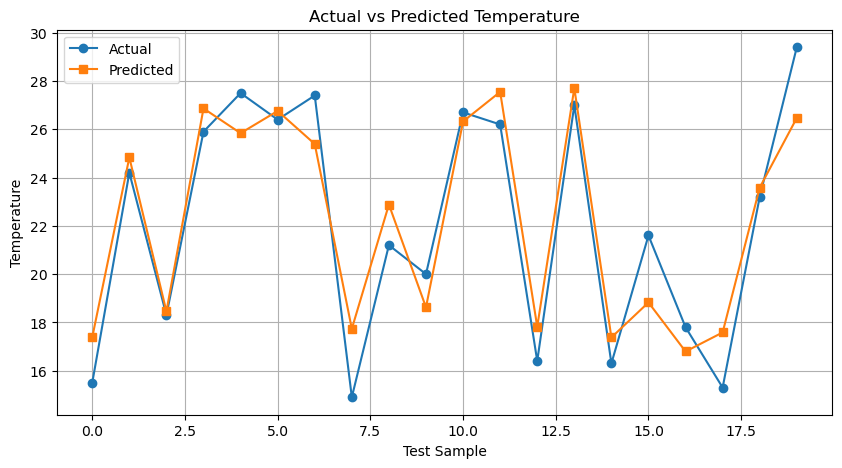

In [11]:
# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    actual,
    label="Actual",
    marker='o'
)

plt.plot(
    predictions,
    label="Predicted",
    marker='s'
)

plt.xlabel("Test Sample")
plt.ylabel("Temperature")

plt.title("Actual vs Predicted Temperature")

plt.legend()

plt.grid(True)

plt.show()